# California Housing Price Prediction
## Linear Regression Model | ML Internship Project

**Objective:** Train a Linear Regression model on the California Housing dataset
and evaluate its performance using MAE, RMSE and R² metrics.

**Tools Used:** Python, Pandas, Scikit-learn, Matplotlib, Seaborn

**Dataset:** California Housing Dataset (20,640 samples, 8 features)

## 1. Importing Libraries

In [20]:
# Cell 1 - Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [21]:
# Cell 2 - Load Dataset
housing = fetch_california_housing()

# Convert to a pandas DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Add the target column (house prices)
df["MedHouseVal"] = housing.target

print("Dataset loaded!")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset loaded!
Shape: (20640, 9)

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 2. Exploratory Data Analysis

In [22]:
# Cell 3 - Basic Info
print("Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

Shape: (20640, 9)

Column Names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

Data Types:
 MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

Missing Values:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [23]:
# Cell 4 - Statistical Summary
df.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


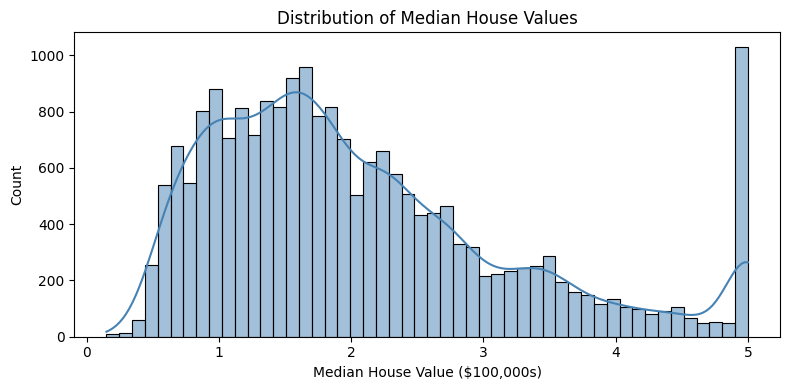

In [24]:
# Cell 5 - Target Distribution
plt.figure(figsize=(8, 4))
sns.histplot(df["MedHouseVal"], bins=50, kde=True, color="steelblue")
plt.title("Distribution of Median House Values")
plt.xlabel("Median House Value ($100,000s)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

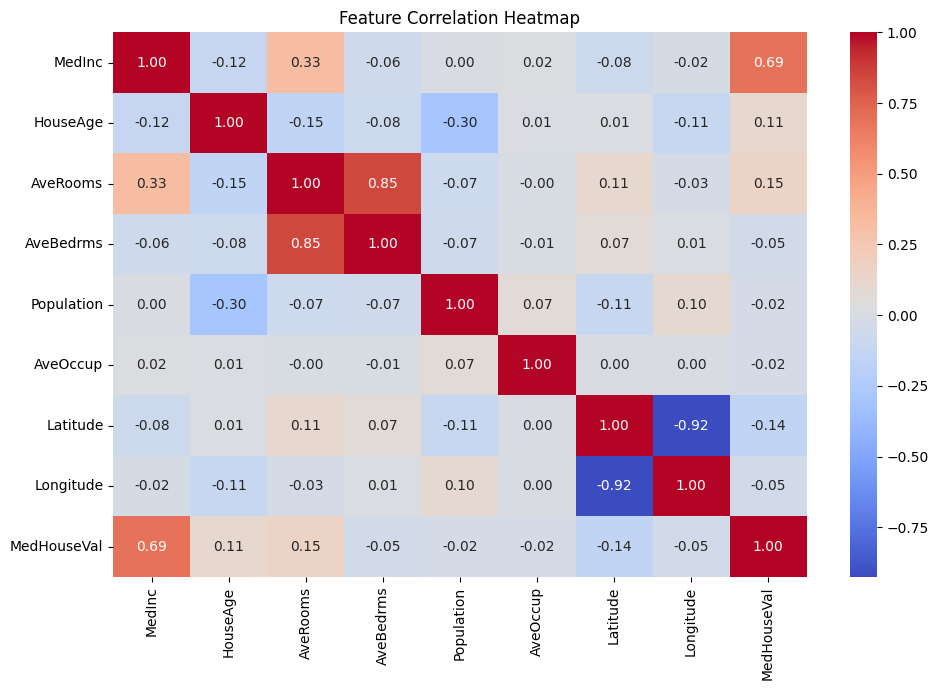

In [25]:
# Cell 6 - Correlation Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [26]:
# Cell 7 - Top Correlations
correlations = df.corr()["MedHouseVal"].sort_values(ascending=False)
print("Correlations with House Value:\n")
print(correlations.round(3))

Correlations with House Value:

MedHouseVal    1.000
MedInc         0.688
AveRooms       0.152
HouseAge       0.106
AveOccup      -0.024
Population    -0.025
Longitude     -0.046
AveBedrms     -0.047
Latitude      -0.144
Name: MedHouseVal, dtype: float64


## 3. Data Preprocessing

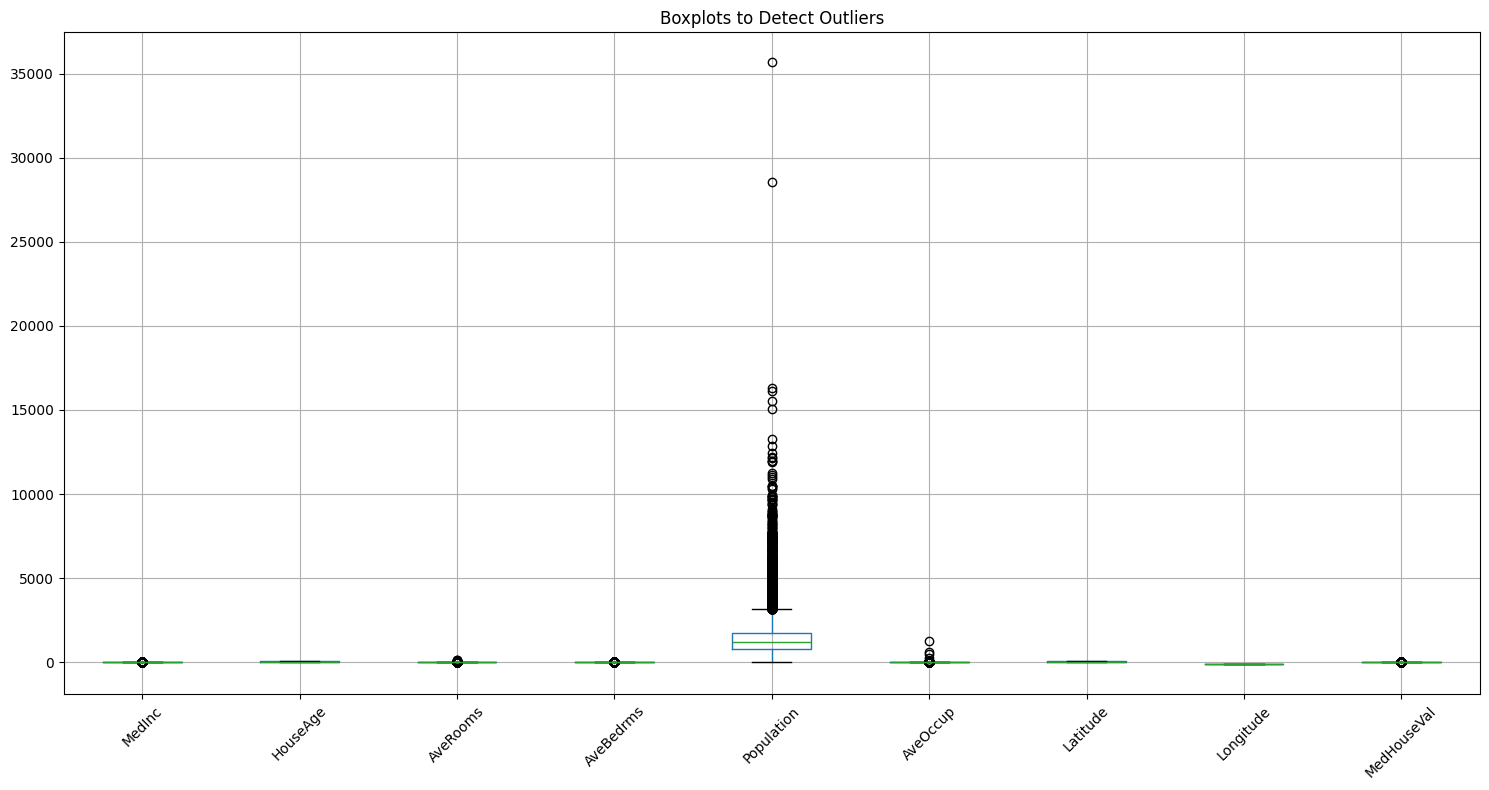

In [27]:
# Cell 8 - Boxplots for Outliers
plt.figure(figsize=(15, 8))
df.boxplot(figsize=(15, 8))
plt.xticks(rotation=45)
plt.title("Boxplots to Detect Outliers")
plt.tight_layout()
plt.show()

In [28]:
# Cell 9 - Features and Target
X = df.drop("MedHouseVal", axis=1)  # All columns except target
y = df["MedHouseVal"]  # Target column only

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeatures used:\n", X.columns.tolist())

Features shape: (20640, 8)
Target shape: (20640,)

Features used:
 ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [29]:
# Cell 10 - Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for readability
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Before Scaling - MedInc mean:", round(X["MedInc"].mean(), 3))
print("After Scaling  - MedInc mean:", round(X_scaled["MedInc"].mean(), 3))
print("\nScaling done! All features now have mean≈0 and std≈1")

Before Scaling - MedInc mean: 3.871
After Scaling  - MedInc mean: 0.0

Scaling done! All features now have mean≈0 and std≈1


## 4. Model Training

In [30]:
# Cell 11 - Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size: ", X_test.shape)
print(f"\n80% data for training → {X_train.shape[0]} rows")
print(f"20% data for testing  → {X_test.shape[0]} rows")

Training set size: (16512, 8)
Testing set size:  (4128, 8)

80% data for training → 16512 rows
20% data for testing  → 4128 rows


In [31]:
# Cell 12 - Train the Model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")
print("\nModel Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature:12s} → {coef:.4f}")
print(f"\nIntercept: {model.intercept_:.4f}")

Model trained successfully!

Model Coefficients:
  MedInc       → 0.8524
  HouseAge     → 0.1224
  AveRooms     → -0.3051
  AveBedrms    → 0.3711
  Population   → -0.0023
  AveOccup     → -0.0366
  Latitude     → -0.8966
  Longitude    → -0.8689

Intercept: 2.0679


In [32]:
# Cell 13 - Predictions
y_pred = model.predict(X_test)

print("Predictions done!")
print("\nSample Predictions vs Actual:")
print(f"{'Actual':>10} | {'Predicted':>10}")
print("-" * 25)
for actual, predicted in zip(y_test[:8], y_pred[:8]):
    print(f"{actual:>10.3f} | {predicted:>10.3f}")

Predictions done!

Sample Predictions vs Actual:
    Actual |  Predicted
-------------------------
     0.477 |      0.719
     0.458 |      1.764
     5.000 |      2.710
     2.186 |      2.839
     2.780 |      2.605
     1.587 |      2.012
     1.982 |      2.646
     1.575 |      2.169


## 5. Model Evaluation

In [33]:
# Cell 14 - Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=" * 40)
print("       MODEL EVALUATION RESULTS")
print("=" * 40)
print(f"  MAE  (Mean Absolute Error) : {mae:.4f}")
print(f"  RMSE (Root Mean Sq. Error) : {rmse:.4f}")
print(f"  R²   (R-Squared Score)     : {r2:.4f}")
print("=" * 40)
print(f"\n  Prices are in $100,000 units")
print(f"  MAE means avg error of ${mae*100000:.0f}")

       MODEL EVALUATION RESULTS
  MAE  (Mean Absolute Error) : 0.5332
  RMSE (Root Mean Sq. Error) : 0.7456
  R²   (R-Squared Score)     : 0.5758

  Prices are in $100,000 units
  MAE means avg error of $53320


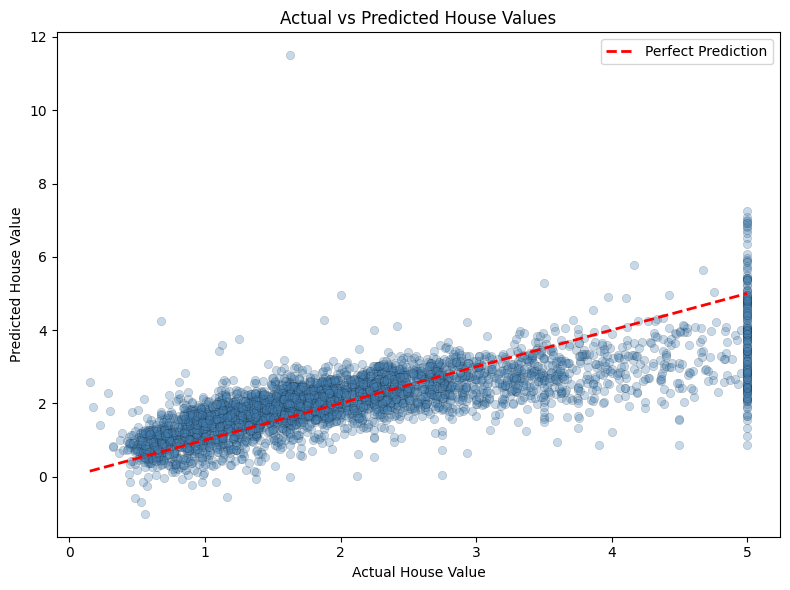

In [34]:
# Cell 15 - Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color="steelblue", edgecolors="k", linewidth=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2,
    label="Perfect Prediction",
)
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Values")
plt.legend()
plt.tight_layout()
plt.show()

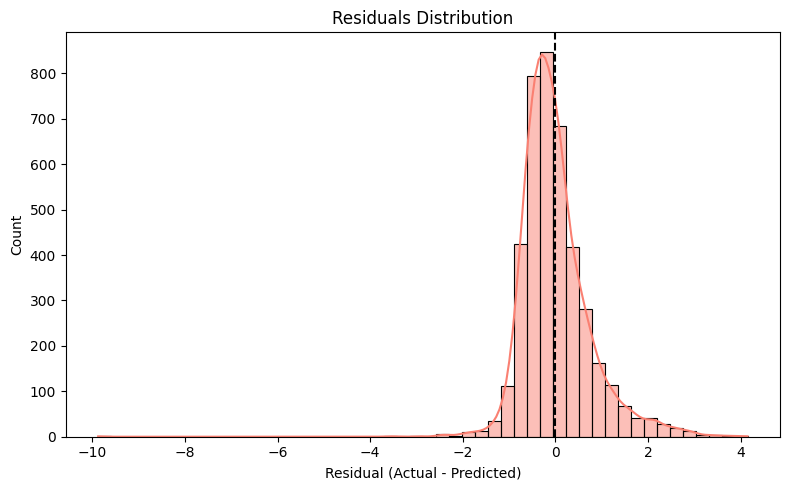

In [35]:
# Cell 16 - Residuals
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=50, kde=True, color="salmon")
plt.axvline(x=0, color="black", linestyle="--", linewidth=1.5)
plt.title("Residuals Distribution")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 6. Saving the Model

In [36]:
# Cell 17 - Save the Model and Scaler
import joblib

# Save the trained model
joblib.dump(model, "california_housing_model.pkl")

# Save the scaler too (important for future predictions!)
joblib.dump(scaler, "california_housing_scaler.pkl")

print("Model saved as: california_housing_model.pkl")
print("Scaler saved as: california_housing_scaler.pkl")

Model saved as: california_housing_model.pkl
Scaler saved as: california_housing_scaler.pkl


In [37]:
# Cell 18 - Reload and Test Saved Model
loaded_model = joblib.load("california_housing_model.pkl")
loaded_scaler = joblib.load("california_housing_scaler.pkl")

# Test with one sample house
sample = X.iloc[0:1]
sample_scaled = loaded_scaler.transform(sample)
prediction = loaded_model.predict(sample_scaled)

print("Model reloaded successfully!")
print(f"\nSample Prediction : ${prediction[0]*100000:.0f}")
print(f"Actual Value      : ${y.iloc[0]*100000:.0f}")

Model reloaded successfully!

Sample Prediction : $415194
Actual Value      : $452600


C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# Cell 18 - Reload and Test Saved Model
loaded_model = joblib.load('california_housing_model.pkl')
loaded_scaler = joblib.load('california_housing_scaler.pkl')

# Test with one sample house
sample = X.iloc[0:1]
sample_scaled = loaded_scaler.transform(sample)
prediction = loaded_model.predict(sample_scaled)

print("Model reloaded successfully!")
print(f"\nSample Prediction : ${prediction[0]*100000:.0f}")
print(f"Actual Value      : ${y.iloc[0]*100000:.0f}")

## 7. Conclusion  ← paste the big conclusion table here

## 8. Conclusion

### Model Performance Summary

| Metric | Value | Interpretation |
|--------|-------|----------------|
| MAE    | 0.5332 | Avg error of ~$53,320 |
| RMSE   | 0.7456 | Sensitive to large errors |
| R²     | 0.5758 | Model explains 57.6% variance |

### Key Findings
- **MedInc** (Median Income) is the strongest predictor of house prices
- **Location** (Latitude & Longitude) has a strong negative influence
- **Population** has very little effect on house prices
- Linear Regression gives a solid **baseline** with R² of 0.57

### Limitations & Future Improvements
- Linear Regression assumes a linear relationship — real data is more complex
- A **Random Forest** or **XGBoost** model could push R² above 0.80
- Outlier removal in Population could improve results

### Files Saved
- `housing_project.ipynb` — Full project notebook
- `california_housing_model.pkl` — Trained model
- `california_housing_scaler.pkl` — Feature scaler

In [38]:
# Cell 19 - Final Summary Print
print("=" * 50)
print("     CALIFORNIA HOUSING PROJECT SUMMARY")
print("=" * 50)
print(f"  Dataset Size     : {df.shape[0]} rows, {df.shape[1]} columns")
print(f"  Training Samples : {X_train.shape[0]}")
print(f"  Testing Samples  : {X_test.shape[0]}")
print("-" * 50)
print(f"  MAE              : {mae:.4f}  (~${mae*100000:.0f})")
print(f"  RMSE             : {rmse:.4f}")
print(f"  R² Score         : {r2:.4f}  ({r2*100:.1f}% variance explained)")
print("-" * 50)
print("  Model saved to   : california_housing_model.pkl")
print("  Scaler saved to  : california_housing_scaler.pkl")
print("=" * 50)
print("  Project Complete!")
print("=" * 50)

     CALIFORNIA HOUSING PROJECT SUMMARY
  Dataset Size     : 20640 rows, 9 columns
  Training Samples : 16512
  Testing Samples  : 4128
--------------------------------------------------
  MAE              : 0.5332  (~$53320)
  RMSE             : 0.7456
  R² Score         : 0.5758  (57.6% variance explained)
--------------------------------------------------
  Model saved to   : california_housing_model.pkl
  Scaler saved to  : california_housing_scaler.pkl
  Project Complete!
